In [2]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
silhouette_score,
davies_bouldin_score,
calinski_harabasz_score
) 

import joblib

In [3]:
#Load CSV 
df = pd.read_csv("../data/Hotel_Reviews.csv")
# Check Shape 
df.shape    #(515738, 17)


(515738, 17)

In [4]:
#PHASE 3 — Understand the Dataset

df.head()  # first 5  rows 
print("======================================")
df.tail()  # last 5 rows
print("=======================================")
df.info()  # Dataset infomation 

print("=====================================")
df.describe()
print("=====================================")

df.columns


<class 'pandas.DataFrame'>
RangeIndex: 515738 entries, 0 to 515737
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   Hotel_Address                               515738 non-null  str    
 1   Additional_Number_of_Scoring                515738 non-null  int64  
 2   Review_Date                                 515738 non-null  str    
 3   Average_Score                               515738 non-null  float64
 4   Hotel_Name                                  515738 non-null  str    
 5   Reviewer_Nationality                        515738 non-null  str    
 6   Negative_Review                             515738 non-null  str    
 7   Review_Total_Negative_Word_Counts           515738 non-null  int64  
 8   Total_Number_of_Reviews                     515738 non-null  int64  
 9   Positive_Review                             515738 non-null  str    
 10  Review_

Index(['Hotel_Address', 'Additional_Number_of_Scoring', 'Review_Date',
       'Average_Score', 'Hotel_Name', 'Reviewer_Nationality',
       'Negative_Review', 'Review_Total_Negative_Word_Counts',
       'Total_Number_of_Reviews', 'Positive_Review',
       'Review_Total_Positive_Word_Counts',
       'Total_Number_of_Reviews_Reviewer_Has_Given', 'Reviewer_Score', 'Tags',
       'days_since_review', 'lat', 'lng'],
      dtype='str')

In [5]:
#PHASE 4 — Data Quality & Cleaning 

df.isnull().sum()  # Missing Values Sum 

df_clean = df.copy() # we creata a copy of dataset

df_clean.duplicated().sum()  # duplicated rows  526 

df_clean = df_clean.drop_duplicates() # duplicates rows will be drop 


df_clean["Reviewer_Score"].describe()

df_clean["Average_Score"].describe()


count    515212.000000
mean          8.397767
std           0.547952
min           5.200000
25%           8.100000
50%           8.400000
75%           8.800000
max           9.800000
Name: Average_Score, dtype: float64

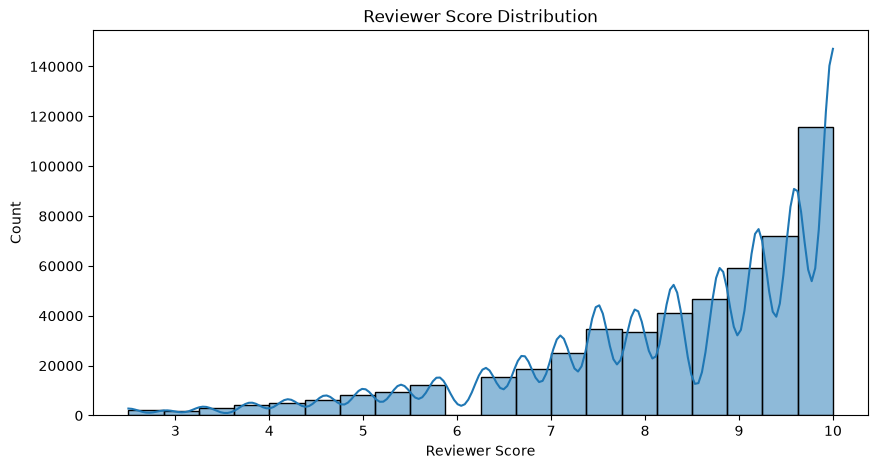

In [6]:
#PHASE 5 — Exploratory Data Analysis :- before clustering understanding the data

#Step 5.1 — Reviewer Score Distribution
plt.figure(figsize=(10, 5))

sns.histplot(
    df_clean["Reviewer_Score"],
    bins=20,
    kde=True
)

plt.title("Reviewer Score Distribution")
plt.xlabel("Reviewer Score")
plt.show()

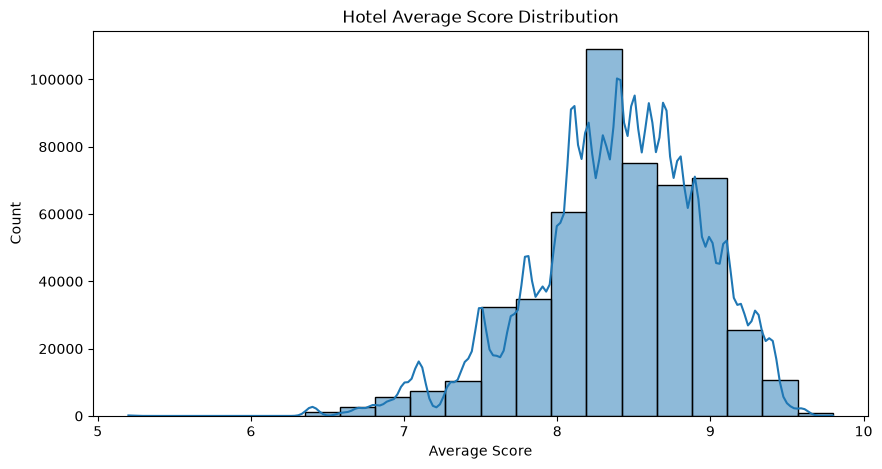

In [7]:
#step 5.2 - Hotel Average  Score 
plt.figure(figsize=(10, 5))

sns.histplot(
    df_clean["Average_Score"],
    bins=20,
    kde=True
)
plt.title("Hotel Average Score Distribution")
plt.xlabel("Average Score")
plt.show()

In [8]:
#step 5.3 - Numer of unique hotels 

df_clean["Hotel_Name"].nunique()

# This is important.

# Because now we decide:

# We should cluster hotels, not 515,738 individual reviews.

1492

In [9]:
#PHASE 6 — Aggregate Reviews into Hotels
hotel_df = df_clean.groupby("Hotel_Name").agg({
    "Average_Score": "median",
    "Reviewer_Score": "mean",
    "Total_Number_of_Reviews":"median",
    "Additional_Number_of_Scoring":"median",
    "Review_Total_Negative_Word_Counts":"mean",
    "Review_Total_Positive_Word_Counts":"mean",
    "Total_Number_of_Reviews_Reviewer_Has_Given":"mean",
    "lat":"first",
    "lng":"first"
}).reset_index()

In [10]:
# Check Result 
hotel_df.shape  # (1492, 10)

hotel_df.head()

,Hotel_Name,Average_Score,Reviewer_Score,Total_Number_of_Reviews,Additional_Number_of_Scoring,Review_Total_Negative_Word_Counts,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,lat,lng
0,11 Cadogan Gardens,8.7,8.845283,393.0,101.0,15.528302,19.974843,7.226415,51.493616,-0.159235
1,1K Hotel,7.7,7.861486,663.0,69.0,24.932432,15.601351,9.141892,48.863932,2.365874
2,25hours Hotel beim MuseumsQuartier,8.8,8.983309,4324.0,391.0,16.161103,21.911466,8.722787,48.206474,16.354630
3,41,9.6,9.711650,244.0,66.0,8.883495,25.300971,6.009709,51.498147,-0.143649
4,45 Park Lane Dorchester Collection,9.4,9.603571,68.0,27.0,6.750000,11.535714,7.214286,51.506371,-0.151536


In [11]:
# phase 7 -Feature Engineering  

#Feature 1 - Sentiment Balance
hotel_df["sentiment_balance"] = (
    hotel_df["Review_Total_Positive_Word_Counts"]
    -
    hotel_df["Review_Total_Negative_Word_Counts"]
) / (
    hotel_df["Review_Total_Positive_Word_Counts"]
    +
    hotel_df["Review_Total_Negative_Word_Counts"]
    + 1
)

In [12]:
#Feature 2 - Review Volume
hotel_df["review_volume"] = (
    hotel_df["Total_Number_of_Reviews"]
    +
    hotel_df["Additional_Number_of_Scoring"]
)

In [13]:
#Feature 3 - Log Review Volume 
hotel_df["log_review_volume"]=np.log1p(
    hotel_df["review_volume"]
)

In [14]:
#PHASE 8 — Validate Engineered Features - Before selecting feature , check them 

hotel_df[[
    "Average_Score",
    "Reviewer_Score",
    "sentiment_balance",
    "review_volume",
    "log_review_volume",
    "Total_Number_of_Reviews_Reviewer_Has_Given"
]].describe()

,Average_Score,Reviewer_Score,sentiment_balance,review_volume,log_review_volume,Total_Number_of_Reviews_Reviewer_Has_Given
count,1492.000000,1492.000000,1492.000000,1492.000000,1492.000000,1492.000000
mean,8.467225,8.468132,0.034400,1488.309651,6.855912,7.825513
std,0.548412,0.622728,0.200036,1578.067727,0.986274,2.501348
min,5.200000,5.121538,-0.547588,50.000000,3.931826,2.571429
25%,8.100000,8.093865,-0.105759,484.500000,6.185178,6.095501
50%,8.500000,8.505886,0.025447,994.500000,6.903245,7.515020
75%,8.900000,8.930305,0.168666,1913.500000,7.557212,9.123615
max,9.800000,9.725000,0.647309,17574.000000,9.774233,46.884615


In [15]:
#Check  missing values
hotel_df.isnull().sum()

Hotel_Name                                     0
Average_Score                                  0
Reviewer_Score                                 0
Total_Number_of_Reviews                        0
Additional_Number_of_Scoring                   0
Review_Total_Negative_Word_Counts              0
Review_Total_Positive_Word_Counts              0
Total_Number_of_Reviews_Reviewer_Has_Given     0
lat                                           17
lng                                           17
sentiment_balance                              0
review_volume                                  0
log_review_volume                              0
dtype: int64

In [16]:
#check infinite values - ideally all should be zero 
np.isinf(
    hotel_df.select_dtypes(include=np.number)
).sum()

Average_Score                                 0
Reviewer_Score                                0
Total_Number_of_Reviews                       0
Additional_Number_of_Scoring                  0
Review_Total_Negative_Word_Counts             0
Review_Total_Positive_Word_Counts             0
Total_Number_of_Reviews_Reviewer_Has_Given    0
lat                                           0
lng                                           0
sentiment_balance                             0
review_volume                                 0
log_review_volume                             0
dtype: int64

In [17]:
#PHASE 9 — Feature Selection : This is where we finally decide what goes into K-Means.

features = [
    "Average_Score",
    "Reviewer_Score",
    "sentiment_balance",
    "log_review_volume",
    "Total_Number_of_Reviews_Reviewer_Has_Given"
]

X = hotel_df[features].copy()


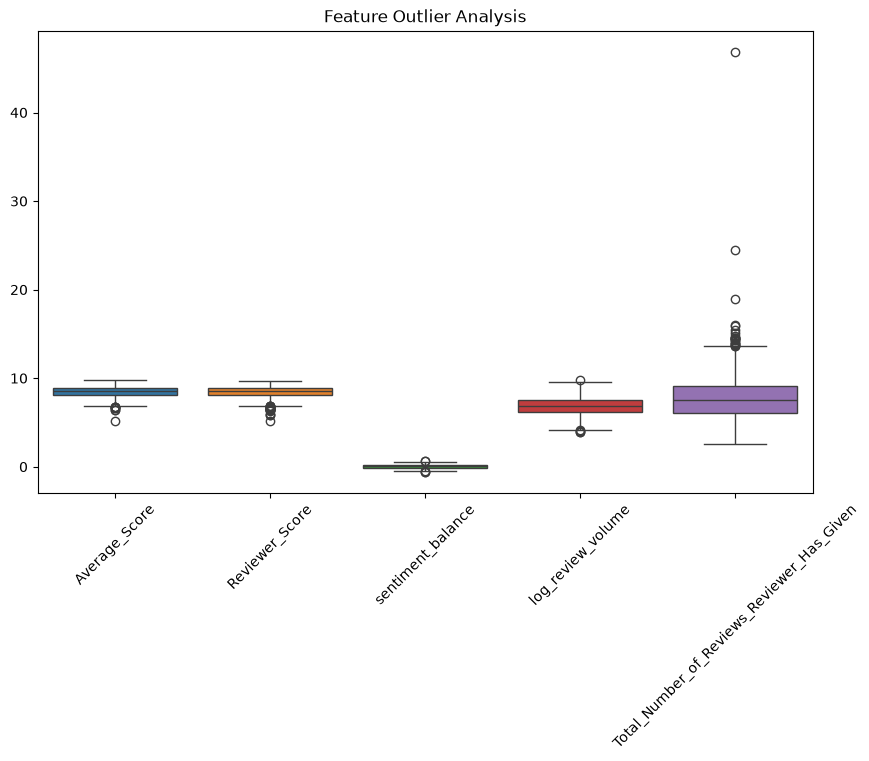

In [18]:
#PHASE 10 — Outlier Analysis

plt.figure(figsize=(10,6))
sns.boxplot(data=X)

plt.xticks(rotation=45)
plt.title("Feature Outlier Analysis")
plt.show()

In [19]:
#Check numerical statistics:
X.describe()

,Average_Score,Reviewer_Score,sentiment_balance,log_review_volume,Total_Number_of_Reviews_Reviewer_Has_Given
count,1492.000000,1492.000000,1492.000000,1492.000000,1492.000000
mean,8.467225,8.468132,0.034400,6.855912,7.825513
std,0.548412,0.622728,0.200036,0.986274,2.501348
min,5.200000,5.121538,-0.547588,3.931826,2.571429
25%,8.100000,8.093865,-0.105759,6.185178,6.095501
50%,8.500000,8.505886,0.025447,6.903245,7.515020
75%,8.900000,8.930305,0.168666,7.557212,9.123615
max,9.800000,9.725000,0.647309,9.774233,46.884615


In [20]:
#PHASE 11 — Feature Scaling

scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X)

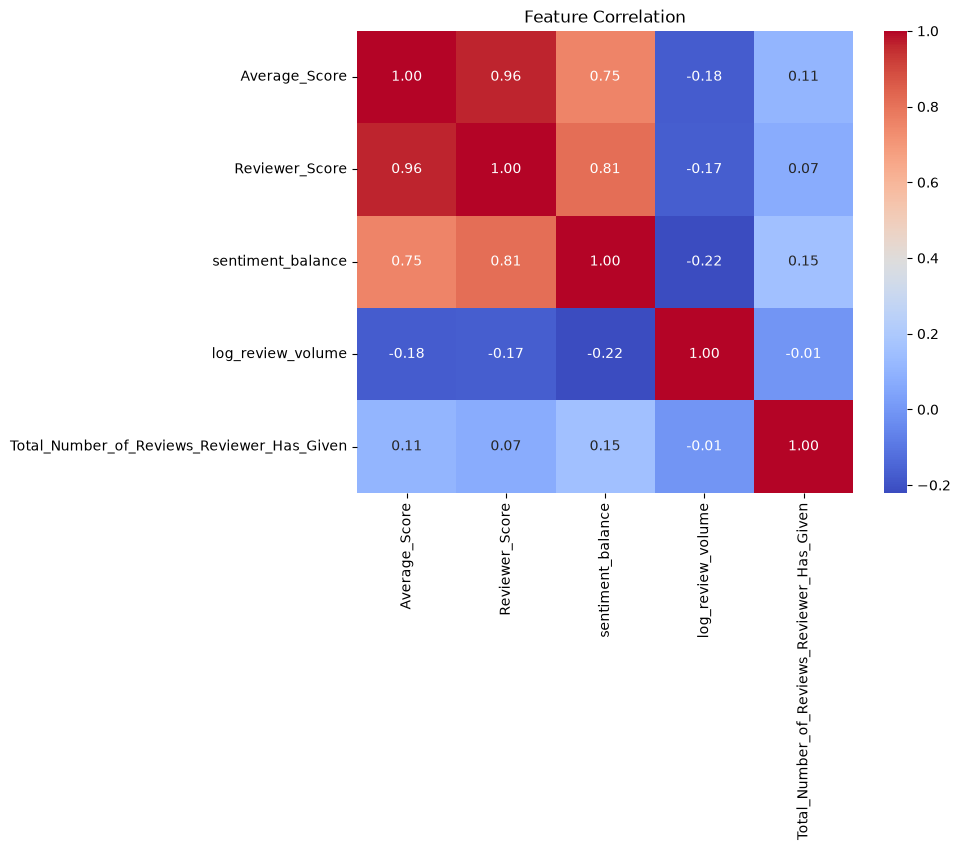

In [21]:
#PHASE 12 — Correlation / Redundancy Check  :-  Before clustering, check:

plt.figure(figsize=(8, 6))

sns.heatmap(
    X.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation")
plt.show()

In [72]:
# PHASE 13 — Clustering Algorithm Experiments

# 13.1 — Import Algorithms and Metrics
from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    DBSCAN,
    SpectralClustering,
    MeanShift
)

from sklearn.mixture import GaussianMixture

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

In [74]:
# 13.2 — K-Means

# We don't know the best K, so test 2–10.

kmeans_results = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    kmeans_results.append({
        "k": k,
        "silhouette": silhouette_score(X_scaled, labels),
        "davies_bouldin": davies_bouldin_score(X_scaled, labels),
        "calinski_harabasz": calinski_harabasz_score(X_scaled, labels)
    })

kmeans_results_df = pd.DataFrame(kmeans_results)

print(kmeans_results_df)

    k  silhouette  davies_bouldin  calinski_harabasz
0   2    0.309732        1.210559         817.949601
1   3    0.236307        1.384795         642.045008
2   4    0.237415        1.321092         570.454032
3   5    0.235634        1.196737         528.505021
4   6    0.215880        1.240496         493.725026
5   7    0.206801        1.264370         460.305968
6   8    0.206465        1.126657         445.729800
7   9    0.206459        1.106789         429.180930
8  10    0.203073        1.176608         412.472634


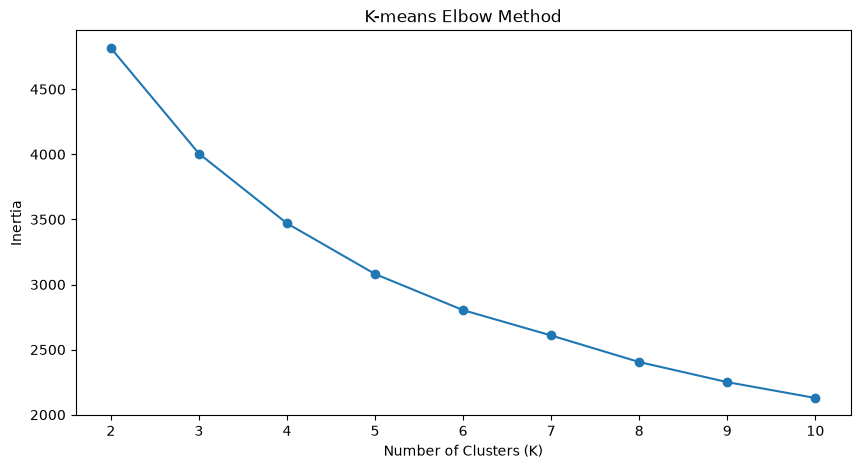

In [ ]:
#Select K using silhouette
best_kmeans_k = kmeans_results_df.loc[
    kmeans_results_df["silhouette"].idxmax(),
    "k"
]

best_kmeans_k = int(best_kmeans_k)

print("Best K-Means K:", best_kmeans_k)

In [24]:
#Method 2 — Silhouette Score

silhouette_scores = []

for k in k_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

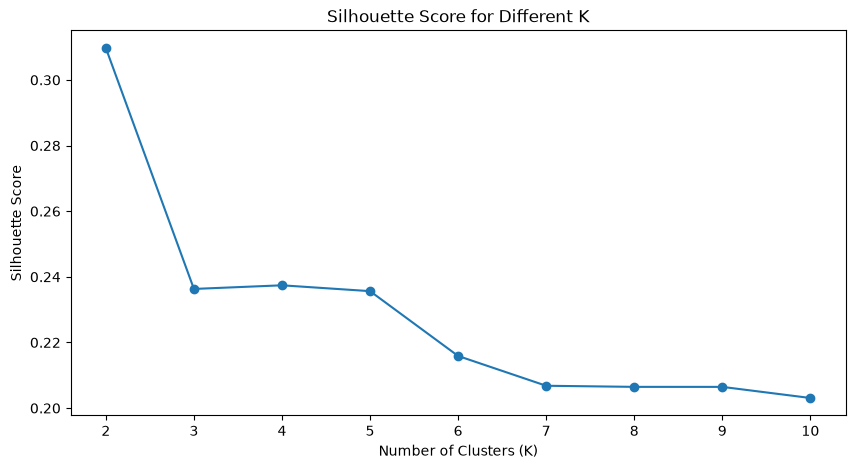

In [25]:
#plot :- 
plt.figure(figsize=(10, 5))

plt.plot(
    k_range,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K")

plt.show()

In [26]:
#— Train Final K-Means :-  Suppose our analysis tells us:

optimal_k = 4
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)
kmeans_labels = kmeans.fit_predict(X_scaled)

hotel_df["KMeans_Cluster"] = kmeans_labels

In [27]:
#PHASE 13.2 — Hierarchical Clustering :- For this we use AgglomerativeClustering.

from sklearn.cluster import AgglomerativeClustering
hierarchical_results = {}

for k in range(2, 11):

    hierarchical = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels = hierarchical.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    hierarchical_results[k] = score


In [28]:
#print 
for k, score in hierarchical_results.items():

    print(
        "K =", k,
        "Silhouette =", score
    )

K = 2 Silhouette = 0.2748020730752948
K = 3 Silhouette = 0.20940673885831834
K = 4 Silhouette = 0.21815811863589535
K = 5 Silhouette = 0.2023485002599322
K = 6 Silhouette = 0.1698627347353442
K = 7 Silhouette = 0.17118916472391613
K = 8 Silhouette = 0.16240329750753923
K = 9 Silhouette = 0.15105587741166113
K = 10 Silhouette = 0.14825426083186494


In [29]:
#Then choose the best-performing K after looking at the results:
best_hierarchical_k = max(
    hierarchical_results,
    key=hierarchical_results.get
)

print(
    "Best Hierarchical K:",
    best_hierarchical_k
)

Best Hierarchical K: 2


In [30]:
#Train the final hierarchical candidate:
hierarchical = AgglomerativeClustering(
    n_clusters=best_hierarchical_k,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(X_scaled)

hotel_df["Hierarchical_Cluster"] = hierarchical_labels

In [31]:
#PHASE 13.3 — DBSCAN  DBSCAN works differently.It doesn't ask us for K.Instead we tune:
#eps  min_samples
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

hotel_df["DBSCAN_Cluster"] = dbscan_labels

In [32]:
# check clusters

unique_labels = np.unique(dbscan_labels)

print("Clusters:", unique_labels)   
# -1 = noise

Clusters: [-1  0  1  2  3  4  5  6]


In [33]:
#check cluster counts 
print(
    hotel_df["DBSCAN_Cluster"].value_counts().sort_index()
)

DBSCAN_Cluster
-1    596
 0    869
 1      5
 2      4
 3      4
 4      2
 5      7
 6      5
Name: count, dtype: int64


In [34]:
# we should test multiple DBSCAN parameters 
dbscan_results = []

for eps in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:

    dbscan = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = dbscan.fit_predict(X_scaled)

    n_clusters = len(
        set(labels) - {-1}
    )

    n_noise = np.sum(
        labels == -1
    )

    if n_clusters >= 2:

        mask = labels != -1

        score = silhouette_score(
            X_scaled[mask],
            labels[mask]
        )

    else:

        score = np.nan

    dbscan_results.append({
        "eps": eps,
        "clusters": n_clusters,
        "noise_points": n_noise,
        "silhouette": score
    })

In [35]:
#Convert to DataFrame:
dbscan_results_df = pd.DataFrame(
    dbscan_results
)

print(dbscan_results_df)

   eps  clusters  noise_points  silhouette
0  0.3         4          1468    0.660311
1  0.4        24          1115    0.095656
2  0.5         7           596   -0.203962
3  0.6         6           332   -0.177905
4  0.7         4           180   -0.000239
5  0.8         2           113    0.424163


In [36]:
#PHASE 13.4 — Gaussian Mixture Model
from sklearn.mixture import GaussianMixture

gmm_results = []

for k in range(2, 11):

    gmm = GaussianMixture(
        n_components=k,
        random_state=42
    )

    labels = gmm.fit_predict(X_scaled)

    silhouette = silhouette_score(
        X_scaled,
        labels
    )

    bic = gmm.bic(X_scaled)

    aic = gmm.aic(X_scaled)

    gmm_results.append({
        "k": k,
        "silhouette": silhouette,
        "bic": bic,
        "aic": aic
    })

In [37]:
#Create DataFrame:

gmm_results_df = pd.DataFrame(
    gmm_results
)

print(gmm_results_df)

    k  silhouette           bic           aic
0   2    0.179891  15037.571480  14819.948696
1   3    0.193803  14901.912628  14572.824515
2   4    0.134486  14664.953755  14224.400314
3   5    0.173240  14871.554617  14319.535847
4   6    0.095235  14828.077984  14164.593887
5   7    0.111448  14917.414328  14142.464902
6   8    0.079410  14907.977550  14021.562795
7   9    0.091518  14975.860269  13977.980186
8  10    0.067431  15055.098159  13945.752748


In [38]:
# For GMM, we can examine:

# Silhouette → higher generally better
# BIC → lower generally better
# AIC → lower generally better

# Then select a suitable K based on the combined evidence.

# Example:
gmm_k = 4

gmm = GaussianMixture(
    n_components=gmm_k,
    random_state=42
)

gmm_labels = gmm.fit_predict(X_scaled)

hotel_df["GMM_Cluster"] = gmm_labels

In [39]:
#phase 13.5 -  MEAN Shift 

from sklearn.cluster import MeanShift

# Mean Shift doesn't require us to specify K.

# Start with:

mean_shift = MeanShift()

mean_shift_labels = mean_shift.fit_predict(
    X_scaled
)

hotel_df["MeanShift_Cluster"] = mean_shift_labels

In [40]:
#checks: 

print(
    hotel_df["MeanShift_Cluster"].value_counts().sort_index()
)

MeanShift_Cluster
0    1468
1       7
2       1
3       1
4      15
Name: count, dtype: int64


In [41]:
#Number of clusters: 
n_mean_shift_clusters = len(
    np.unique(mean_shift_labels)
)

print(
    "Mean Shift clusters:",
    n_mean_shift_clusters
)

Mean Shift clusters: 5


In [42]:
#then : Mean Shift can sometimes produce a surprising number of clusters, so we need to inspect the result rather than assuming it is suitable.

mean_shift_score = silhouette_score(
    X_scaled,
    mean_shift_labels
)

print(
    "Mean Shift Silhouette:",
    mean_shift_score
)

Mean Shift Silhouette: 0.3401151714973028


In [43]:
# we should compare all method 
#  K-Means
# Hierarchical
# DBSCAN
# GMM
# Mean Shift
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

In [44]:
# create a helper function 
def evaluate_clustering(X, labels):

    unique_labels = set(labels)

    # Remove DBSCAN noise
    if -1 in unique_labels:

        mask = labels != -1

        X_eval = X[mask]
        labels_eval = labels[mask]

    else:

        X_eval = X
        labels_eval = labels

    n_clusters = len(
        np.unique(labels_eval)
    )

    if n_clusters < 2:

        return {
            "Silhouette": np.nan,
            "Davies_Bouldin": np.nan,
            "Calinski_Harabasz": np.nan,
            "Clusters": n_clusters
        }

    return {
        "Silhouette": silhouette_score(
            X_eval,
            labels_eval
        ),

        "Davies_Bouldin": davies_bouldin_score(
            X_eval,
            labels_eval
        ),

        "Calinski_Harabasz": calinski_harabasz_score(
            X_eval,
            labels_eval
        ),

        "Clusters": n_clusters
    }

In [45]:
results = {}
# K-Means
results["K-Means"] = evaluate_clustering(
    X_scaled,
    kmeans_labels
)


# Hierarchical
results["Hierarchical"] = evaluate_clustering(
    X_scaled,
    hierarchical_labels
)


#DBSCAN
results["DBSCAN"] = evaluate_clustering(
    X_scaled,
    dbscan_labels
)

#GMM
results["GMM"] = evaluate_clustering(
    X_scaled,
    gmm_labels
)

#Mean Shift
results["Mean Shift"] = evaluate_clustering(
    X_scaled,
    mean_shift_labels
)

In [46]:
#Convert to DataFrame:

comparison_df = pd.DataFrame(
    results
).T

print(comparison_df)

              Silhouette  Davies_Bouldin  Calinski_Harabasz  Clusters
K-Means         0.237415        1.321092         570.454032       4.0
Hierarchical    0.274802        1.244293         669.384940       2.0
DBSCAN         -0.203962        0.999172          10.791708       7.0
GMM             0.134486        1.830183         184.427272       4.0
Mean Shift      0.340115        0.627469          46.873525       5.0


In [47]:

# Mean Shift is best so we used that 
print("Number of clusters:",
      len(np.unique(mean_shift_labels)))

Number of clusters: 5


In [48]:
#Check cluster sizes:

print(
    hotel_df["MeanShift_Cluster"]
    .value_counts()
    .sort_index()
)

MeanShift_Cluster
0    1468
1       7
2       1
3       1
4      15
Name: count, dtype: int64


In [49]:
#2. Confirm its evaluation:-  Run all three metrics on Mean Shift:

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

silhouette = silhouette_score(
    X_scaled,
    mean_shift_labels
)

davies = davies_bouldin_score(
    X_scaled,
    mean_shift_labels
)

calinski = calinski_harabasz_score(
    X_scaled,
    mean_shift_labels
)

print("Mean Shift Evaluation")
print("---------------------")
print("Silhouette Score:", silhouette)
print("Davies-Bouldin Index:", davies)
print("Calinski-Harabasz Score:", calinski)

Mean Shift Evaluation
---------------------
Silhouette Score: 0.3401151714973028
Davies-Bouldin Index: 0.6274687417233825
Calinski-Harabasz Score: 46.87352514353363


In [50]:
#3. Make Mean Shift your final cluster column :- Instead of keeping:

hotel_df["MeanShift_Cluster"]

0       0
1       0
2       0
3       0
4       0
       ..
1487    0
1488    0
1489    0
1490    0
1491    0
Name: MeanShift_Cluster, Length: 1492, dtype: int64

In [51]:
#we can create one standard final column:

hotel_df["Cluster"] = mean_shift_labels

#Now throughout the rest of the project, use:

hotel_df["Cluster"]

0       0
1       0
2       0
3       0
4       0
       ..
1487    0
1488    0
1489    0
1490    0
1491    0
Name: Cluster, Length: 1492, dtype: int64

In [52]:
# 4. Profile the Mean Shift clusters

# Now we want to understand what each cluster actually represents.

# Use the same features we selected earlier:

features = [
    "Average_Score",
    "Reviewer_Score",
    "sentiment_balance",
    "log_review_volume",
    "Total_Number_of_Reviews_Reviewer_Has_Given"
]

#Then:

cluster_profile = hotel_df.groupby(
    "Cluster"
)[features].mean()

cluster_profile

,Average_Score,Reviewer_Score,sentiment_balance,log_review_volume,Total_Number_of_Reviews_Reviewer_Has_Given
Cluster,,,,,
0,8.48767,8.495297,0.040306,6.866627,7.778837
1,8.10000,7.633038,-0.187726,5.340970,14.655672
2,8.40000,8.153846,0.096354,5.446737,46.884615
3,7.90000,7.277273,-0.171582,5.181784,24.500000
4,6.68000,6.299562,-0.430323,6.719731,5.490530


In [53]:
#Also check cluster sizes:

cluster_sizes = (
    hotel_df["Cluster"]
    .value_counts()
    .sort_index()
)

print(cluster_sizes)

Cluster
0    1468
1       7
2       1
3       1
4      15
Name: count, dtype: int64


In [54]:
# PHASE 18 — Cluster Visualization Using PCA :-  We have 5 dimensions.
# We cannot easily draw 5-dimensional data.
# Use PCA to visualize it in 2 dimensions.

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [55]:
#create dataframe 
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = hotel_df["Cluster"].values

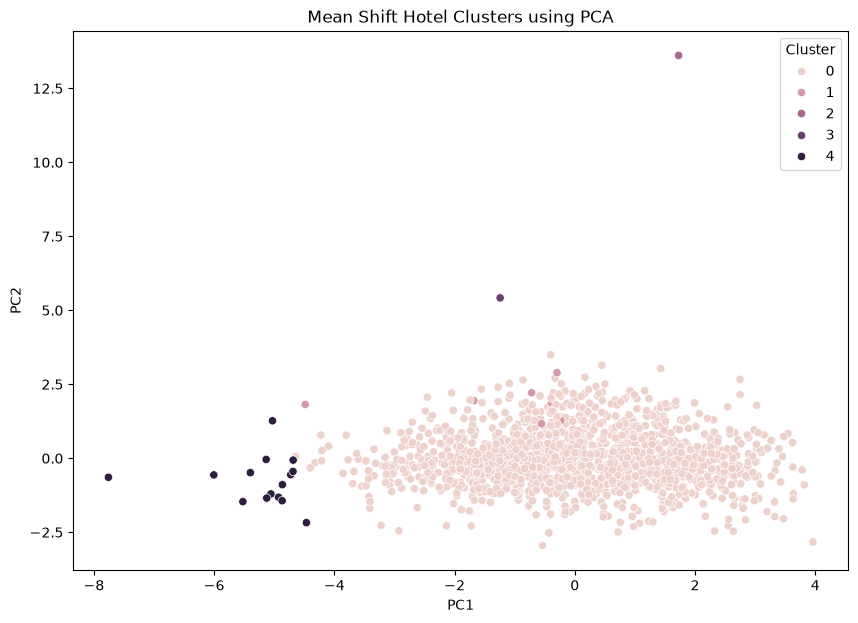

In [56]:
#plot 
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster"
)

plt.title("Mean Shift Hotel Clusters using PCA")
plt.show()

In [57]:
#6. Check how much information PCA retained
print(
    "Explained variance:",
    pca.explained_variance_ratio_
)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)

Explained variance: [0.55388876 0.19903538]
Total explained variance: 0.7529241347875248


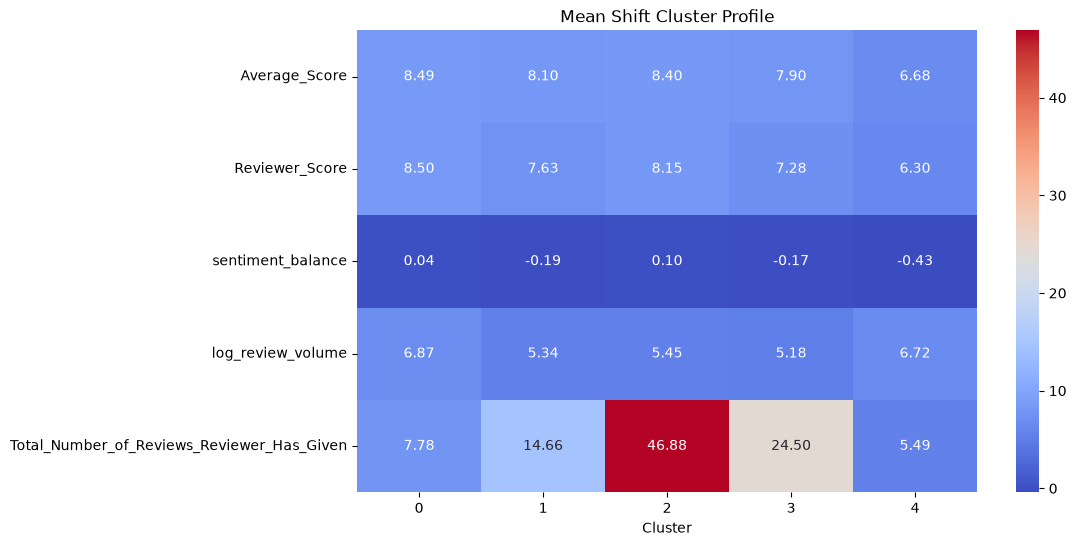

In [59]:
# 8. Create a cluster profile heatmap

# This is useful for your project presentation/interview.

plt.figure(figsize=(10, 6))

sns.heatmap(
    cluster_profile.T,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Mean Shift Cluster Profile"
)

plt.show()

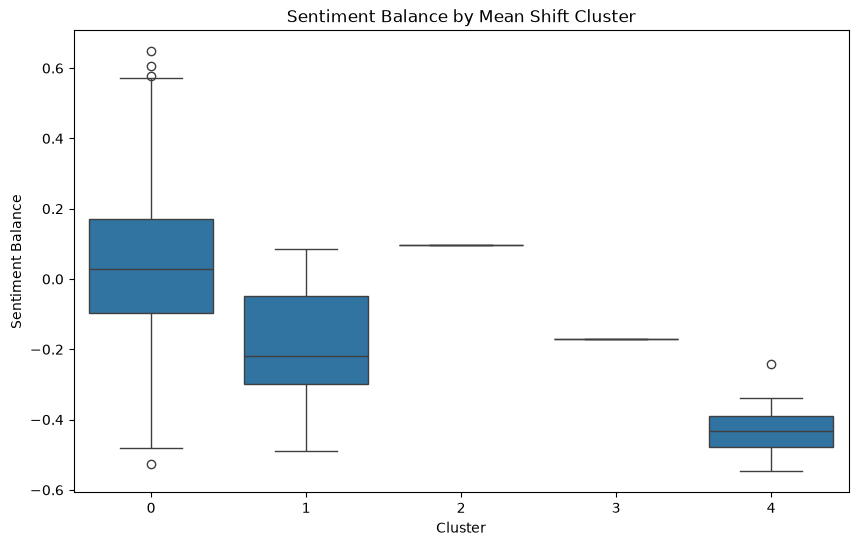

In [61]:
#Sentiment Balance Boxplot
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=hotel_df,
    x="Cluster",
    y="sentiment_balance"
)

plt.title("Sentiment Balance by Mean Shift Cluster")
plt.xlabel("Cluster")
plt.ylabel("Sentiment Balance")

plt.show()

# This tells us how the sentiment-balance distribution differs between clusters.

# Remember that our sentiment_balance is based on positive/negative review word counts, so it is a proxy—not a true NLP sentiment score.

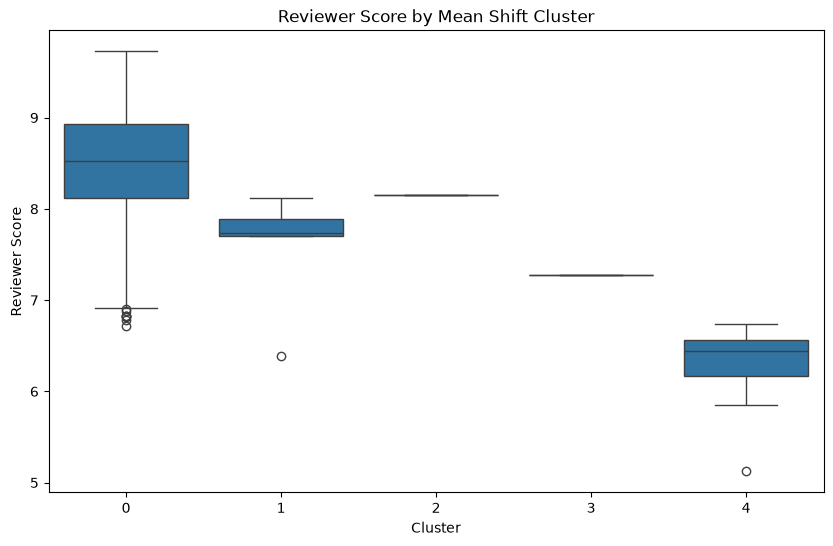

In [62]:
#Reviewer Score Boxplot
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=hotel_df,
    x="Cluster",
    y="Reviewer_Score"
)

plt.title("Reviewer Score by Mean Shift Cluster")
plt.xlabel("Cluster")
plt.ylabel("Reviewer Score")

plt.show()

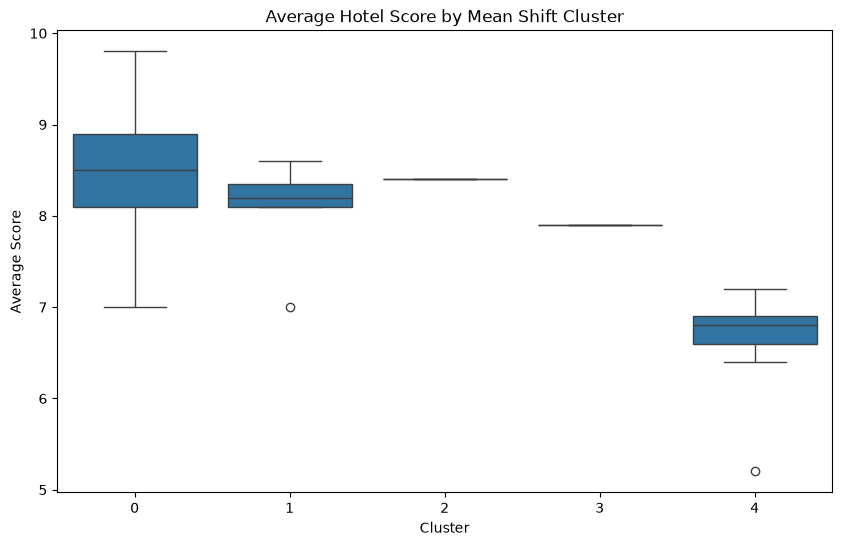

In [63]:
#Average Score
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=hotel_df,
    x="Cluster",
    y="Average_Score"
)

plt.title("Average Hotel Score by Mean Shift Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Score")

plt.show()

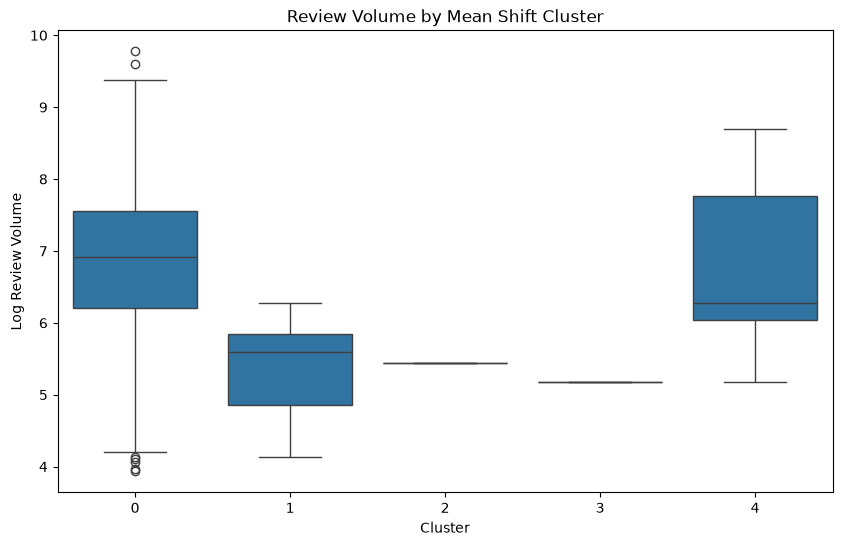

In [64]:
#Review Volume
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=hotel_df,
    x="Cluster",
    y="log_review_volume"
)

plt.title("Review Volume by Mean Shift Cluster")
plt.xlabel("Cluster")
plt.ylabel("Log Review Volume")

plt.show()

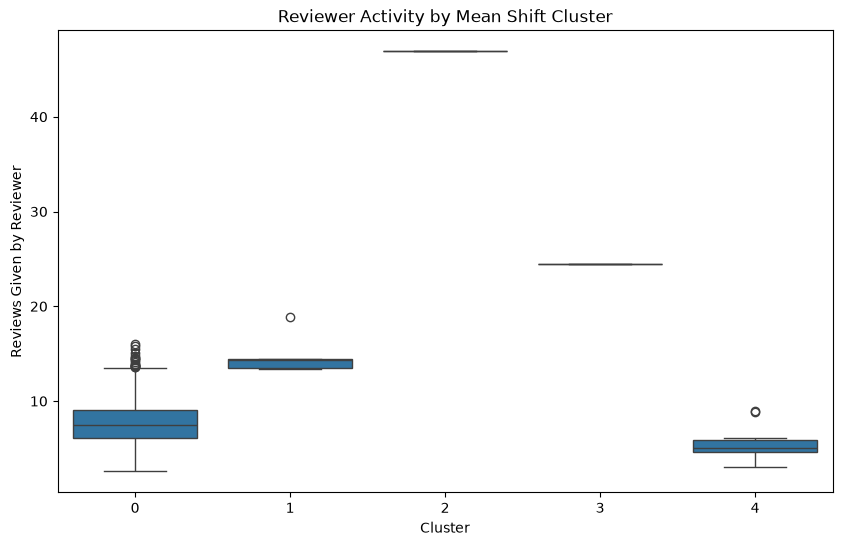

In [65]:
#Reviewer Activity
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=hotel_df,
    x="Cluster",
    y="Total_Number_of_Reviews_Reviewer_Has_Given"
)

plt.title("Reviewer Activity by Mean Shift Cluster")
plt.xlabel("Cluster")
plt.ylabel("Reviews Given by Reviewer")

plt.show()

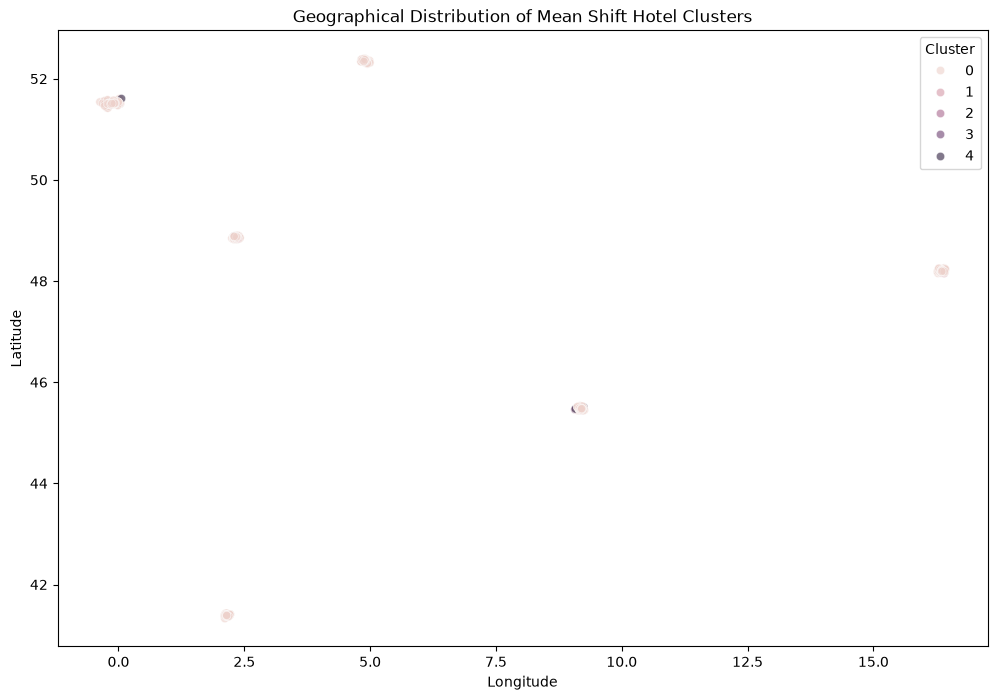

In [69]:
#7. Geographic visualization  we use - lat, lng
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=hotel_df,
    x="lng",
    y="lat",
    hue="Cluster",
    alpha=0.6
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "Geographical Distribution of Mean Shift Hotel Clusters"
)

plt.show()


In [71]:
#PHASE 20 — Cluster Interpretation
cluster_profile = hotel_df.groupby("Cluster")[features].mean()

cluster_profile

,Average_Score,Reviewer_Score,sentiment_balance,log_review_volume,Total_Number_of_Reviews_Reviewer_Has_Given
Cluster,,,,,
0,8.48767,8.495297,0.040306,6.866627,7.778837
1,8.10000,7.633038,-0.187726,5.340970,14.655672
2,8.40000,8.153846,0.096354,5.446737,46.884615
3,7.90000,7.277273,-0.171582,5.181784,24.500000
4,6.68000,6.299562,-0.430323,6.719731,5.490530
